<a href="https://colab.research.google.com/github/m1naku/neuro/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961__%D0%97%D0%BD%D0%B0%D0%BA%D0%BE%D0%BC%D1%81%D1%82%D0%B2%D0%BE_%D1%81_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%BC%D0%B8_%D1%81%D0%B5%D1%82%D1%8F%D0%BC%D0%B8_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1 "Знакомство с нейронными сетями"

**Цель работы:** ознакомление со структурой нейронных сетей. Получение навыка программирования нейронных сетей.

# Теоретическая часть: от биологического нейрона к математической модели

## 1. Биологический нейрон как прототип

Нейрон — это структурно‑функциональная единица нервной системы, специализированная клетка, которая принимает, обрабатывает и передаёт информацию в виде электрохимических сигналов.


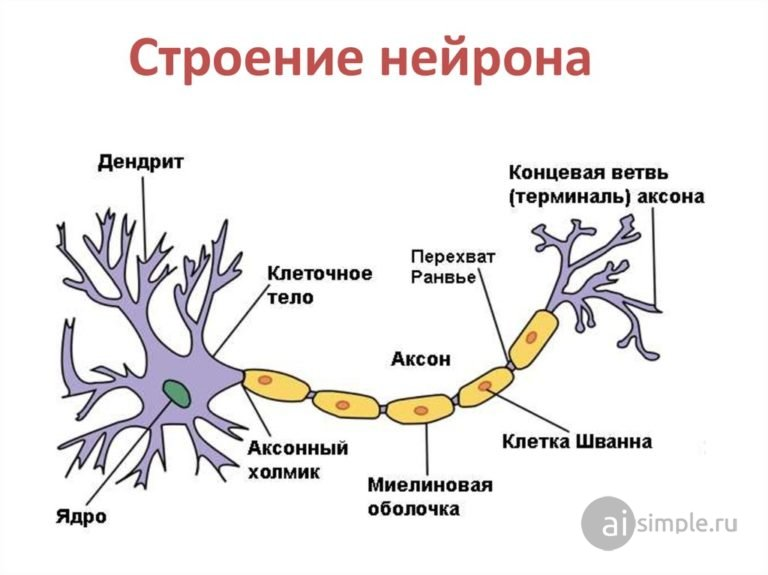

Источник: https://aisimple.ru/27-iskusstvenniy-neiron.html

Типичный нейрон состоит из трёх основных частей:

- **Сома (тело клетки)** — содержит ядро и органеллы, обеспечивает метаболизм и «жизнедеятельность» клетки.
- **Дендриты** — многочисленные короткие разветвлённые отростки, принимающие входящие сигналы от других нейронов или рецепторов и передающие их к телу нейрона.
- **Аксон** — обычно один длинный отросток, проводящий возбуждение от тела нейрона к другим нейронам, мышечным или железистым клеткам.

На окончаниях аксона формируются **синапсы** — специализированные контакты с другими клетками. В синапсах происходит высвобождение нейромедиаторов, которые изменяют состояние постсинаптической мембраны и тем самым усиливают или ослабляют вероятность возбуждения следующего нейрона.

Работа нейрона носит **пороговый** характер. Суммарное действие всех возбуждающих и тормозящих синаптических входов интегрируется в особой области — аксонном холмике. Если мембранный потенциал достигает порогового значения, генерируется **потенциал действия** («спайк»), который распространяется по аксону; если нет — нейрон остаётся в неактивном состоянии.

Ключевые свойства биологического нейрона, которые важны для моделирования:
- множество входов и один выход;
- взвешенное (неравнозначное) влияние разных входов;
- наличие порога активации;
- нелинейная «ответная» реакция (всё‑или‑ничего для спайков, но с возможной аналоговой предобработкой на дендритах).

Именно эти свойства переносятся в вычислительные модели искусственных нейронов.



### 2. Абстракция: от биологии к формальному нейрону

При построении математической модели реальные биофизические детали (ионы, мембранный потенциал, морфология дендритного дерева) заменяются более простой **формальной схемой**. В этой схеме:

- каждый биологический синапс заменяется **весовым коэффициентом** $(w_i)$, отражающим силу и знак влияния соответствующего входа;
- дендриты и сома — это блок **суммирования** (сумматор), где складываются все взвешенные входные сигналы;
- порог возбуждения и нелинейная реакция на суммарный вход моделируются **функцией активации** $(f(\cdot))$.

Таким образом, биологический нейрон аппроксимируется формальной структурой: «взвешенная сумма входов → нелинейное преобразование → выход». Это приближение сохраняет ключевую логику обработки информации, при этом становится удобным для математического анализа и программной реализации.



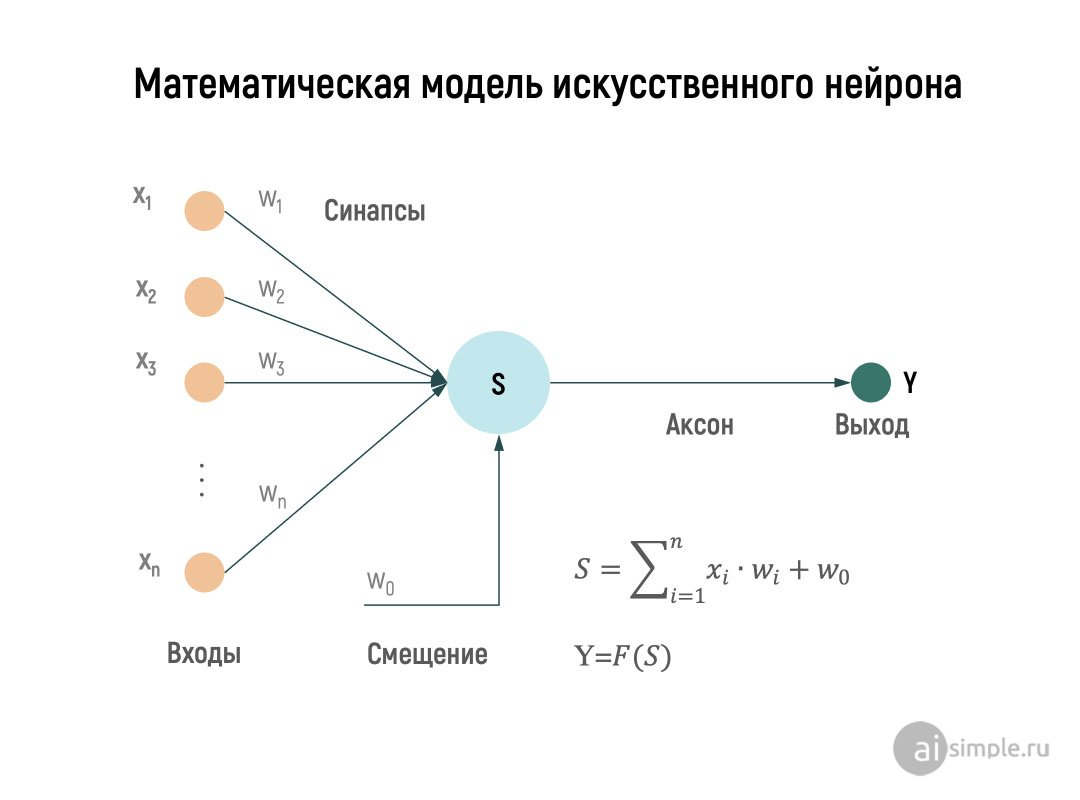

Источник: https://aisimple.ru/27-iskusstvenniy-neiron.html

## 3. Искусственный нейрон и его структура

Искусственный нейрон (формальный нейрон, перцептронный элемент) рассматривается как вычислительный блок, который принимает на вход вектор чисел и возвращает одно число — выходной сигнал.

Пусть на нейрон подаётся входной вектор  
$$
\mathbf{x} = (x_1, x_2, \dots, x_n),
$$
где $x_i$ — числовые характеристики входного сигнала (признаки, значения сигналов предыдущего слоя и т.п.).

С этим вектором связана такая же размерность **весов**  
$$
\mathbf{w} = (w_1, w_2, \dots, w_n),
$$
где $w_i$ характеризует силу и знак синаптической связи с соответствующим входом. Положительные веса моделируют возбуждающие связи, отрицательные — тормозящие.

Дополнительно вводится **смещение (bias)** $b$, которое играет роль регулируемого порога активации и позволяет сдвигать область «чувствительности» нейрона.




### 3.1. Линейный сумматор

На первом этапе работы нейрона вычисляется взвешенная сумма входов с учётом смещения:  
$$
s = \sum_{i=1}^{n} w_i x_i + b.
$$

Здесь:  
- $s$ — результирующий суммарный вход (степень возбуждения нейрона),  
- $w_i$ — веса синапсов,  
- $x_i$ — компоненты входного вектора,  
- $b$ — смещение (порог),  
- $n$ — число входов искусственного нейрона.  

Можно записать эту операцию в векторной форме как  
$$
s = \mathbf{w}^\top \mathbf{x} + b,
$$
то есть нейрон реализует скалярное произведение вектора весов и вектора входов, дополненное смещением.

### 3.2. Нелинейный преобразователь (функция активации)

Второй этап — применение **функции активации** $f(\cdot)$, которая моделирует нелинейную реакцию нейрона на суммарный вход:  
$$
y = f(s).
$$

Здесь $y$ — выходной сигнал нейрона. Именно за счёт нелинейности $f$ многослойные сети из таких нейронов могут аппроксимировать сложные нелинейные зависимости, в отличие от чисто линейных моделей.

Итоговая математическая модель искусственного нейрона:  
$$
\boxed{
\begin{aligned}
s &= \sum_{i=1}^{n} w_i x_i + b,\\
y &= f(s).
\end{aligned}
}
$$

Векторно:  
$$
y = f(\mathbf{w}^\top \mathbf{x} + b).
$$

В таком виде нейрон можно рассматривать как **элементарный вычислитель функции** от векторного аргумента, где параметры $\mathbf{w}, b$ подбираются в процессе обучения.

## 4. Классификация синаптических связей и интерпретация весов

В биологических нейронных сетях синапсы делятся на **возбуждающие** и **тормозящие** — в одном случае они повышают вероятность генерации потенциала действия, в другом — понижают. Аналогичная идея реализуется в математической модели через знак весов:

- $w_i > 0$: возбуждающее влияние соответствующего входа;  
- $w_i < 0$: тормозящее влияние;  
- $w_i \approx 0$: слабое или практически отсутствующее влияние данного входа на итоговый выход нейрона.

Таким образом, обученный набор весов $\mathbf{w}$ можно интерпретировать как распределение «важности» и характера влияния различных признаков (входов) на решение, принимаемое нейроном.

## 5. Функции активации нейрона

Выбор функции активации определяет характер зависимости выхода $y$ от суммарного входа $s$. В практических задачах используют разные типы активационных функций, каждая из которых имеет свой диапазон значений, гладкость и особенности производной.

Ниже приведены классические примеры функций активации (обозначение $f(s)$ совпадает с обозначениями в методических материалах).

### 5.1. Линейная и полулинейная функции

**Линейная функция:**

$$f(s) = k s, \quad s \in (-\infty, \infty)$$

где $k$ — коэффициент наклона. Она не вносит нелинейности и используется в основном в выходных нейронах для задач регрессии, где требуется непрерывный выход.

#### Практическое задание 5.1.1

Реализуйте функцию `linear_activation` и её производную:


In [ ]:
def linear_activation(s, k=1.0):
    """
    Линейная функция активации.

    Args:
        s: скалярное значение или массив numpy
        k: коэффициент наклона (по умолчанию 1.0)

    Returns:
        Значение функции f(s) = k*s
    """
    # Реализуйте функцию
    return k * s

def linear_activation_derivative(s, k=1.0):
    """
    Производная линейной функции активации.

    Args:
        s: скалярное значение или массив numpy
        k: коэффициент наклона

    Returns:
        Значение производной f'(s) = k
    """
    # Реализуйте производную
    return k


# Проверка
import numpy as np

s_test = np.array([-2, -1, 0, 1, 2])
k = 2.0

# Проверка функции
result = linear_activation(s_test, k)
print(f"Linear activation: {result}")
assert np.allclose(result, k * s_test), "Ошибка в linear_activation"

# Проверка производной
deriv = linear_activation_derivative(s_test, k)
print(f"Linear derivative: {deriv}")
assert np.allclose(deriv, k), "Ошибка в linear_activation_derivative"

print("✓ Линейная функция верна!")

---

**Полулинейная (нечёткая линейная) функция:**

$$f(s) = \begin{cases} k s, & s > 0,\\ 0, & s \le 0 \end{cases}, \quad s \in (0, \infty)$$

Такая функция реализует «обрезку» отрицательных значений и используется как простая модель порогового включения с линейным ростом.

#### Практическое задание 5.1.2

Реализуйте функцию `relu_activation` (полулинейная функция, частный случай ReLU):

In [ ]:
def relu_activation(s, k=1.0):
    """
    Полулинейная функция активации (ReLU).

    Args:
        s: скалярное значение или массив numpy
        k: коэффициент наклона в области s > 0 (обычно 1.0)

    Returns:
        Значение функции: k*s если s > 0, иначе 0
    """
    # Реализуйте функцию
    return np.where (s > 0, k * s, 0)

def relu_activation_derivative(s, k=1.0):
    """
    Производная полулинейной функции активации.

    Args:
        s: скалярное значение или массив numpy
        k: коэффициент наклона

    Returns:
        Значение производной: k если s > 0, иначе 0
    """
    # Реализуйте производную

    return np.where (s > 0, k, 0)


# Проверка
s_test = np.array([-2, -1, 0, 0.5, 1, 2])
k = 1.0

result = relu_activation(s_test, k)
print(f"ReLU activation: {result}")
expected = np.array([0, 0, 0, 0.5, 1, 2])
assert np.allclose(result, expected), f"Ошибка: получили {result}, ожидали {expected}"

deriv = relu_activation_derivative(s_test, k)
print(f"ReLU derivative: {deriv}")
expected_deriv = np.array([0, 0, 0, 1, 1, 1])
assert np.allclose(deriv, expected_deriv), f"Ошибка в производной"

print("✓ Полулинейная функция верна!")

---

### 5.2. Сигмоидальные функции

**Логистическая сигмоида:**

$$f(s) = \frac{1}{1 + e^{-a s}}, \quad s \in (-\infty, \infty)$$

где $a > 0$ задаёт «крутизну» перехода. Эта функция:
- ограничена на интервале $(0, 1)$,
- гладка и дифференцируема на всей оси,
- имеет простую производную:
  $$f'(s) = a f(s)(1 - f(s))$$

что удобно для алгоритмов обучения по градиенту.

#### Практическое задание 5.2.1

Реализуйте сигмоидальную функцию и её производную:

In [ ]:
def sigmoid_activation(s, a=1.0):
    """
    Логистическая сигмоидальная функция активации.

    Args:
        s: скалярное значение или массив numpy
        a: параметр крутизны (по умолчанию 1.0)

    Returns:
        Значение функции
    """
    # Реализуйте функцию
    # Подсказка: используйте np.exp() для вычисления экспоненты
    return 1 / (1 + np.exp(-a * s))

def sigmoid_activation_derivative(s, a=1.0):
    """
    Производная сигмоидальной функции активации.

    Args:
        s: скалярное значение или массив numpy
        a: параметр крутизны

    Returns:
        Значение производной
    """
    # Реализуйте производную
    # Используйте уже реализованную sigmoid_activation()
    sig = sigmoid_activation(s, a)
    return a * sig * (1 - sig)


# Проверка
s_test = np.array([-5, -2, 0, 2, 5])
a = 1.0

result = sigmoid_activation(s_test, a)
print(f"Sigmoid activation: {result}")

# Проверка диапазона значений (должны быть в (0, 1))
assert np.all(result > 0) and np.all(result < 1), "Ошибка: сигмоида вне диапазона (0, 1)"

# Проверка симметрии вокруг нуля: f(0) должна быть 0.5
assert np.isclose(sigmoid_activation(0, a), 0.5), "Ошибка: f(0) != 0.5"

deriv = sigmoid_activation_derivative(s_test, a)
print(f"Sigmoid derivative: {deriv}")

# Производная на 0 должна быть максимальной (=a/4)
assert np.isclose(sigmoid_activation_derivative(0, a), a/4), "Ошибка: максимум производной"

print("✓ Сигмоидальная функция верна!")

---

**Гиперболический тангенс:**

$$f(s) = \tanh(a s) = \frac{e^{a s} - e^{-a s}}{e^{a s} + e^{-a s}}, \quad s \in (-\infty, \infty)$$

Он также является сигмоидальной функцией, но отображает ось в диапазон $(-1, 1)$. Такая центровка вокруг нуля часто облегчает обучение, так как среднее значение активаций ближе к нулю.

#### Практическое задание 5.2.2

Реализуйте функцию `tanh_activation`:

In [ ]:
def tanh_activation(s, a=1.0):
    """
    Гиперболический тангенс как функция активации.

    Args:
        s: скалярное значение или массив numpy
        a: параметр крутизны

    Returns:
        Значение функции f(s) = tanh(a*s)
    """
    # Реализуйте функцию
    # Подсказка: используйте np.tanh() или формулу (exp(as) - exp(-as)) / (exp(as) + exp(-as))
    return np.tanh(a * s)

def tanh_activation_derivative(s, a=1.0):
    """
    Производная гиперболического тангенса.

    Args:
        s: скалярное значение или массив numpy
        a: параметр крутизны

    Returns:
        Значение производной f'(s) = a * (1 - tanh^2(a*s))
    """
    # Реализуйте производную
    th = tanh_activation(s, a)
    # Производная: a * (1 - tanh^2)
    return a * (1 - th**2)


# Проверка
s_test = np.array([-5, -2, 0, 2, 5])
a = 1.0

result = tanh_activation(s_test, a)
print(f"Tanh activation: {result}")

# Проверка диапазона значений (должны быть в (-1, 1))
assert np.all(result > -1) and np.all(result < 1), "Ошибка: tanh вне диапазона (-1, 1)"

# Проверка нечётности: tanh(-x) = -tanh(x)
assert np.allclose(tanh_activation(-s_test, a), -tanh_activation(s_test, a)), "Ошибка: tanh не нечётная"

deriv = tanh_activation_derivative(s_test, a)
print(f"Tanh derivative: {deriv}")

# На 0 производная должна быть максимальной (=a)
assert np.isclose(tanh_activation_derivative(0, a), a), "Ошибка: максимум производной tanh"

print("✓ Гиперболический тангенс верен!")

### 5.3. Пороговые и ступенчатые функции

**Пороговая функция (единичная ступенька):**

$$f(s) = \begin{cases} 0, & s < 0,\\ 1, & s \ge 0 \end{cases}$$

Использовалась в классических перцептронах для реализации булевых функций: нейрон «включён» (1) или «выключен» (0) в зависимости от того, превышен ли порог.

#### Практическое задание 5.3.1

Реализуйте пороговую функцию:

In [ ]:
def threshold_activation(s, threshold=0.0):
    """
    Пороговая функция активации (ступенька Хэвисайда).

    Args:
        s: скалярное значение или массив numpy
        threshold: пороговое значение (по умолчанию 0.0)

    Returns:
        Значение функции: 1 если s >= threshold, иначе 0
    """
    # Реализуйте функцию
    # Подсказка: используйте np.where() или условие s >= threshold
    return np.where( s >= threshold, 1, 0)


# Проверка
s_test = np.array([-2, -1, 0, 1, 2])
threshold = 0.0

result = threshold_activation(s_test, threshold)
print(f"Threshold activation: {result}")

expected = np.array([0, 0, 1, 1, 1])
assert np.allclose(result, expected), f"Ошибка: получили {result}, ожидали {expected}"

print("✓ Пороговая функция верна!")

---

**Знаковая функция:**

$$f(s) = \begin{cases} 1, & s > 0,\\ -1, & s \le 0 \end{cases}$$

даёт два симметричных уровня выхода $-1$ и $1$ и удобна в задачах, где классы кодируются такими значениями.

---

### 5.4. Современные активационные функции

В современных глубоких сетях часто применяют простые и вычислительно эффективные функции:

**ReLU (Rectified Linear Unit):**

$$f(s) = \max(0, s)$$

Обнуляет отрицательные входы и оставляет положительные без изменений. Обеспечивает разрежённость активаций и снижает проблему затухающего градиента.

**Leaky ReLU:**

$$f(s) = \begin{cases} s, & s \ge 0,\\ \alpha s, & s < 0, \quad (0 < \alpha \ll 1) \end{cases}$$

сохраняет небольшой градиент для отрицательных значений, что уменьшает риск «вымерших» нейронов.

---

In [ ]:
# @title Визулизация функций активации
import numpy as np
import matplotlib.pyplot as plt

def plot_activation_functions():
    """
    Визуализирует основные функции активации используя стандартные библиотеки.
    """
    s = np.linspace(-5, 5, 200)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Сравнение функций активации нейронов', fontsize=16, fontweight='bold')

    # 1. Линейная
    ax = axes[0, 0]
    ax.plot(s, s, label='k=1.0', linewidth=2, color='blue')
    ax.plot(s, 0.5 * s, label='k=0.5', linewidth=2, color='orange')
    ax.set_title('Линейная функция\nf(s) = k·s', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('s', fontsize=11)
    ax.set_ylabel('f(s)', fontsize=11)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # 2. ReLU
    ax = axes[0, 1]
    relu = np.maximum(0, s)
    leaky_relu = np.where(s > 0, s, 0.1 * s)
    ax.plot(s, relu, label='ReLU', linewidth=2, color='green')
    ax.plot(s, leaky_relu, label='Leaky ReLU (α=0.1)', linewidth=2, color='lime', linestyle='--')
    ax.set_title('ReLU семейство\nf(s) = max(0, s)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('s', fontsize=11)
    ax.set_ylabel('f(s)', fontsize=11)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # 3. Сигмоида
    ax = axes[0, 2]
    sigmoid_1 = 1 / (1 + np.exp(-s))
    sigmoid_05 = 1 / (1 + np.exp(-0.5 * s))
    ax.plot(s, sigmoid_1, label='a=1.0', linewidth=2, color='purple')
    ax.plot(s, sigmoid_05, label='a=0.5', linewidth=2, color='magenta', linestyle='--')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title('Логистическая сигмоида\nf(s) = 1/(1+e⁻ᵃˢ)', fontsize=12, fontweight='bold')
    ax.set_ylim([-0.1, 1.1])
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('s', fontsize=11)
    ax.set_ylabel('f(s)', fontsize=11)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # 4. Tanh
    ax = axes[1, 0]
    tanh_1 = np.tanh(s)
    tanh_05 = np.tanh(0.5 * s)
    ax.plot(s, tanh_1, label='a=1.0', linewidth=2, color='red')
    ax.plot(s, tanh_05, label='a=0.5', linewidth=2, color='coral', linestyle='--')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title('Гиперболический тангенс\nf(s) = tanh(as)', fontsize=12, fontweight='bold')
    ax.set_ylim([-1.1, 1.1])
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('s', fontsize=11)
    ax.set_ylabel('f(s)', fontsize=11)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # 5. Пороговая (Heaviside step function)
    ax = axes[1, 1]
    threshold = np.where(s >= 0, 1, 0)
    ax.plot(s, threshold, label='threshold=0', linewidth=2.5, color='darkblue', drawstyle='steps-post')
    ax.set_title('Пороговая функция (Heaviside)\nf(s) = {0 if s<0, 1 if s≥0}', fontsize=12, fontweight='bold')
    ax.set_ylim([-0.1, 1.1])
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('s', fontsize=11)
    ax.set_ylabel('f(s)', fontsize=11)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # 6. Знаковая (Sign function)
    ax = axes[1, 2]
    sign = np.where(s > 0, 1, -1)
    ax.plot(s, sign, label='sign', linewidth=2.5, color='darkorange', drawstyle='steps-post')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title('Знаковая функция (Sign)\nf(s) = {-1 if s≤0, 1 if s>0}', fontsize=12, fontweight='bold')
    ax.set_ylim([-1.5, 1.5])
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('s', fontsize=11)
    ax.set_ylabel('f(s)', fontsize=11)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    plt.tight_layout()
    plt.show()


# Запустите для просмотра
plot_activation_functions()


In [ ]:
# @title Визулизация работы
from ipywidgets import interact, FloatSlider, Dropdown
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


@interact(
    x1=FloatSlider(min=-2, max=2, step=0.1, value=0.5, description='Вход x₁:'),
    x2=FloatSlider(min=-2, max=2, step=0.1, value=0.8, description='Вход x₂:'),
    w1=FloatSlider(min=-2, max=2, step=0.1, value=0.5, description='Вес w₁:'),
    w2=FloatSlider(min=-2, max=2, step=0.1, value=-0.3, description='Вес w₂:'),
    b=FloatSlider(min=-2, max=2, step=0.1, value=0, description='Смещение b:'),
    activation=Dropdown(options=['sigmoid', 'relu', 'tanh', 'linear'],
                       value='sigmoid', description='Активация:')
)
def neuron_demo(x1, x2, w1, w2, b, activation):
    """Интерактивная демонстрация работы нейрона"""

    # Вычисления
    s = x1 * w1 + x2 * w2 + b

    # Применение активации
    if activation == 'sigmoid':
        y = 1 / (1 + np.exp(-np.clip(s, -500, 500)))  # защита от переполнения
        activation_formula = 'σ(s) = 1/(1+e^(-s))'
        y_range = '[0, 1]'
    elif activation == 'relu':
        y = max(0, s)
        activation_formula = 'ReLU(s) = max(0, s)'
        y_range = '[0, ∞)'
    elif activation == 'tanh':
        y = np.tanh(s)
        activation_formula = 'tanh(s)'
        y_range = '[-1, 1]'
    else:  # linear
        y = s
        activation_formula = 'f(s) = s'
        y_range = '(-∞, ∞)'

    # Создание фигуры с двумя панелями
    fig = plt.figure(figsize=(16, 7))
    gs = fig.add_gridspec(2, 2, width_ratios=[3, 2], height_ratios=[1, 1])

    # === ЛЕВАЯ ПАНЕЛЬ: Схема нейрона ===
    ax_schema = fig.add_subplot(gs[:, 0])
    ax_schema.set_xlim(0, 10)
    ax_schema.set_ylim(0, 10)
    ax_schema.set_aspect('equal')
    ax_schema.axis('off')

    # Позиции элементов
    inp_positions = [(1.5, 7), (1.5, 3)]
    sum_pos = (4, 5)
    act_pos = (6.5, 5)
    out_pos = (8.5, 5)

    # 1. Входные узлы
    for i, ((x_pos, y_pos), val, w) in enumerate(zip(inp_positions, [x1, x2], [w1, w2])):
        # Цвет по знаку веса
        color = '#27ae60' if w > 0 else '#e74c3c'
        edge_color = '#229954' if w > 0 else '#c0392b'

        # Круг входа
        circle = mpatches.Circle((x_pos, y_pos), 0.5,
                                facecolor=color, edgecolor=edge_color,
                                linewidth=2.5, alpha=0.7, zorder=5)
        ax_schema.add_patch(circle)
        ax_schema.text(x_pos, y_pos, f'x{i+1}\n{val:.2f}',
                      ha='center', va='center', fontsize=11,
                      fontweight='bold', color='white', zorder=6)

        # Стрелка к сумматору (толщина пропорциональна весу)
        lw = 1 + 3 * min(abs(w), 2) / 2
        ax_schema.annotate('', xy=(sum_pos[0] - 0.6, sum_pos[1]),
                          xytext=(x_pos + 0.52, y_pos),
                          arrowprops=dict(arrowstyle='->', color=color,
                                        lw=lw, alpha=0.8), zorder=3)

        # Подпись веса
        mid_x, mid_y = (x_pos + sum_pos[0]) / 2, (y_pos + sum_pos[1]) / 2
        weight_text = f'w{i+1}={w:.2f}'
        weight_sign = '(+) возбуждающая' if w > 0 else '(-) тормозящая'
        ax_schema.text(mid_x - 0.3, mid_y + 0.5, weight_text,
                      fontsize=9, color=edge_color, fontweight='bold',
                      bbox=dict(boxstyle='round,pad=0.3',
                               facecolor='white', alpha=0.8), zorder=4)

    # 2. Смещение (bias)
    bias_pos = (2, 1.2)
    bias_circle = mpatches.Circle(bias_pos, 0.35,
                                 facecolor='#95a5a6', edgecolor='#7f8c8d',
                                 linewidth=2, alpha=0.8, zorder=5)
    ax_schema.add_patch(bias_circle)
    ax_schema.text(bias_pos[0], bias_pos[1], f'b\n{b:.2f}',
                  ha='center', va='center', fontsize=9,
                  fontweight='bold', color='white', zorder=6)
    ax_schema.annotate('', xy=(sum_pos[0] - 0.5, sum_pos[1] - 0.4),
                      xytext=(bias_pos[0] + 0.35, bias_pos[1] + 0.2),
                      arrowprops=dict(arrowstyle='->', color='#7f8c8d',
                                    lw=1.5, alpha=0.7), zorder=3)

    # 3. Сумматор
    sum_rect = mpatches.FancyBboxPatch((sum_pos[0] - 0.6, sum_pos[1] - 0.7),
                                      1.2, 1.4, boxstyle="round,pad=0.1",
                                      facecolor='#3498db', edgecolor='#2980b9',
                                      linewidth=3, alpha=0.9, zorder=5)
    ax_schema.add_patch(sum_rect)
    ax_schema.text(sum_pos[0], sum_pos[1] + 0.3, 'Σ',
                  ha='center', va='center', fontsize=24,
                  fontweight='bold', color='white', zorder=6)
    ax_schema.text(sum_pos[0], sum_pos[1] - 0.3, f's={s:.3f}',
                  ha='center', va='center', fontsize=9,
                  fontweight='bold', color='white', zorder=6)

    # Стрелка сумматор → активация
    ax_schema.annotate('', xy=(act_pos[0] - 0.65, act_pos[1]),
                      xytext=(sum_pos[0] + 0.6, sum_pos[1]),
                      arrowprops=dict(arrowstyle='->', color='#34495e',
                                    lw=2.5), zorder=3)

    # 4. Функция активации
    act_rect = mpatches.FancyBboxPatch((act_pos[0] - 0.65, act_pos[1] - 0.7),
                                      1.3, 1.4, boxstyle="round,pad=0.1",
                                      facecolor='#9b59b6', edgecolor='#8e44ad',
                                      linewidth=3, alpha=0.9, zorder=5)
    ax_schema.add_patch(act_rect)
    ax_schema.text(act_pos[0], act_pos[1] + 0.2, 'f(s)',
                  ha='center', va='center', fontsize=14,
                  fontweight='bold', color='white', zorder=6)
    ax_schema.text(act_pos[0], act_pos[1] - 0.35, activation,
                  ha='center', va='center', fontsize=9,
                  fontweight='bold', color='white',
                  style='italic', zorder=6)

    # Стрелка активация → выход
    ax_schema.annotate('', xy=(out_pos[0] - 0.52, out_pos[1]),
                      xytext=(act_pos[0] + 0.65, act_pos[1]),
                      arrowprops=dict(arrowstyle='->', color='#34495e',
                                    lw=2.5), zorder=3)

    # 5. Выходной узел
    out_circle = mpatches.Circle(out_pos, 0.5,
                                facecolor='#f39c12', edgecolor='#e67e22',
                                linewidth=2.5, alpha=0.9, zorder=5)
    ax_schema.add_patch(out_circle)
    ax_schema.text(out_pos[0], out_pos[1], f'y\n{y:.3f}',
                  ha='center', va='center', fontsize=11,
                  fontweight='bold', color='white', zorder=6)

    # Заголовок схемы
    ax_schema.text(5, 9.2, 'Архитектура одного искусственного нейрона',
                  ha='center', va='center', fontsize=14, fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1',
                           edgecolor='#34495e', linewidth=2))

    # === ПРАВАЯ ВЕРХНЯЯ ПАНЕЛЬ: Формулы ===
    ax_formulas = fig.add_subplot(gs[0, 1])
    ax_formulas.axis('off')
    ax_formulas.set_xlim(0, 1)
    ax_formulas.set_ylim(0, 1)

    formulas_text = f"""Математическая модель:

[1] Взвешенная сумма:
    s = w1*x1 + w2*x2 + b
    s = {w1:.2f}*{x1:.2f} + {w2:.2f}*{x2:.2f} + {b:.2f}
    s = {s:.4f}

[2] Функция активации:
    {activation_formula}
    Диапазон: {y_range}

[3] Выход нейрона:
    y = f(s) = {y:.4f}
"""

    ax_formulas.text(0.5, 0.5, formulas_text, ha='center', va='center',
                    fontsize=10, family='monospace',
                    bbox=dict(boxstyle='round,pad=1', facecolor='#fef9e7',
                             edgecolor='#f39c12', linewidth=2))

    # === ПРАВАЯ НИЖНЯЯ ПАНЕЛЬ: График функции активации ===
    ax_plot = fig.add_subplot(gs[1, 1])

    s_range = np.linspace(-5, 5, 200)
    if activation == 'sigmoid':
        y_range_vals = 1 / (1 + np.exp(-s_range))
    elif activation == 'relu':
        y_range_vals = np.maximum(0, s_range)
    elif activation == 'tanh':
        y_range_vals = np.tanh(s_range)
    else:  # linear
        y_range_vals = s_range

    ax_plot.plot(s_range, y_range_vals, linewidth=3, color='#9b59b6', label=activation_formula)
    ax_plot.axvline(x=s, color='#e74c3c', linewidth=2, linestyle='--', label=f's = {s:.3f}')
    ax_plot.axhline(y=y, color='#f39c12', linewidth=2, linestyle='--', label=f'y = {y:.3f}')
    ax_plot.plot(s, y, 'ro', markersize=12, markeredgewidth=2,
                markeredgecolor='darkred', zorder=5)

    ax_plot.grid(True, alpha=0.3, linestyle=':', linewidth=1)
    ax_plot.set_xlabel('Взвешенная сумма s', fontsize=11, fontweight='bold')
    ax_plot.set_ylabel('Выход y', fontsize=11, fontweight='bold')
    ax_plot.set_title(f'График функции {activation}', fontsize=12, fontweight='bold')
    ax_plot.legend(loc='best', fontsize=9, framealpha=0.9)
    ax_plot.axhline(y=0, color='k', linewidth=0.5)
    ax_plot.axvline(x=0, color='k', linewidth=0.5)

    plt.tight_layout()
    plt.show()

## 6. Интерпретация нейрона как элемента вычислительной модели

С точки зрения обработки информации, искусственный нейрон реализует следующую последовательность преобразований:

1. Принимает на вход числовой вектор $\mathbf{x}$ (сенсорные данные, признаки, выходы предыдущего слоя).
2. Вычисляет взвешенную сумму входов и смещение:
   $$s = \mathbf{w}^\top \mathbf{x} + b$$
3. Применяет нелинейную функцию активации:
   $$y = f(s)$$
4. Передаёт результат $y$ на вход нейронам следующего слоя или формирует выход всей сети.

При объединении большого количества таких нейронов в слои и сети получается мощный **универсальный аппроксиматор**: многослойные нейронные сети могут приближать широкий класс нелинейных многомерных функций при достаточном количестве нейронов и корректной настройке параметров.

Таким образом, путь от биологического нейрона к искусственному — это переход от сложной биофизической системы к абстрактному вычислительному блоку, который сохраняет ключевой принцип: интеграция множества входов с различной силой влияния и нелинейное принятие решения на основе их совокупного эффекта.

## 7. Классификация нейронных сетей

Нейронные сети можно классифицировать по различным критериям: архитектуре связей, типу обработки информации и назначению.

### 7.1. По архитектуре связей

**Однослойные сети**

Простейшая архитектура, где входной слой напрямую связан с выходным слоем через один слой весов. Классический пример — **перцептрон Розенблатта** (1958), способный решать только линейно разделимые задачи.

**Многослойные сети прямого распространения (feedforward)**

Содержат один или несколько **скрытых слоёв** между входом и выходом. Информация движется строго в одном направлении: вход → скрытые слои → выход. Многослойный перцептрон (MLP) с нелинейными функциями активации является универсальным аппроксиматором и может решать задачи произвольной сложности при достаточном числе нейронов.

**Рекуррентные сети (recurrent)**

Содержат **обратные связи**: выходы нейронов могут возвращаться на входы того же или предыдущих слоёв. Это позволяет сети иметь «память» и обрабатывать последовательности данных. Применяются для анализа временных рядов, обработки текста и речи. Примеры: сети Элмана, Джордана, LSTM.

**Свёрточные сети (convolutional, CNN)**

Специализированная архитектура для обработки данных с пространственной структурой (изображения, видео). Используют операцию **свёртки** вместо полносвязных слоёв, что существенно сокращает число параметров и учитывает локальные паттерны.

### 7.2. По типу связей между слоями

**Полносвязные (fully connected)**

Каждый нейрон слоя $q$ соединён со всеми нейронами слоя $q+1$. Количество параметров (весов) между двумя слоями: $n_q \times n_{q+1}$, где $n_q$ — число нейронов в слое $q$.

**Частично связанные**

Нейроны соединены только с определённым подмножеством нейронов следующего слоя. Используется для снижения вычислительной сложности и введения локальных ограничений (например, свёрточные слои в CNN).

### 7.3. По способу обучения

**Обучение с учителем (supervised learning)**

Сеть обучается на размеченных данных: для каждого входа известен правильный выход. Алгоритм корректирует веса, минимизируя ошибку между предсказанием сети и истинным значением. Применяется в задачах классификации и регрессии.

**Обучение без учителя (unsupervised learning)**

Сеть самостоятельно выявляет закономерности в данных без явных меток. Примеры задач: кластеризация, снижение размерности, обнаружение аномалий. Самоорганизующиеся карты Кохонена, автокодировщики.

**Обучение с подкреплением (reinforcement learning)**

Сеть учится взаимодействовать со средой, получая награды или штрафы за свои действия. Используется в робототехнике, играх, управлении.

### 7.4. По типу решаемых задач

| Тип задачи | Описание | Пример архитектуры |
|------------|----------|-------------------|
| **Классификация** | Отнесение входа к одному из заранее известных классов | MLP, CNN для изображений |
| **Регрессия** | Предсказание непрерывного числового значения | MLP с линейным выходным слоем |
| **Распознавание образов** | Идентификация объектов на изображениях, в звуке | CNN, RNN |
| **Прогнозирование** | Предсказание будущих значений временного ряда | LSTM, GRU |
| **Генерация данных** | Создание новых объектов (изображений, текста) | GAN, VAE, Трансформеры |

### 7.5. Теорема об универсальной аппроксимации

Фундаментальный результат теории нейронных сетей: **многослойная сеть прямого распространения с одним скрытым слоем** достаточной ширины и нелинейной функцией активации может **с произвольной точностью аппроксимировать любую непрерывную функцию** на компактном множестве.

Это означает, что теоретически даже простая двухслойная сеть способна решить практически любую задачу. Однако на практике глубокие сети (с большим числом слоёв) обучаются эффективнее и требуют меньше нейронов для достижения той же точности.

### 7.6. Выбор архитектуры

При проектировании нейронной сети учитывают:

- **Тип данных**: табличные данные → MLP; изображения → CNN; последовательности → RNN/LSTM
- **Размер данных**: малые датасеты требуют более простых архитектур во избежание переобучения
- **Вычислительные ресурсы**: глубокие сети требуют больше памяти и времени
- **Интерпретируемость**: простые архитектуры легче анализировать

---


## Порядок выполнения работы

### 1. Создание схемы нейронной сети согласно варианту таблицы

Рассмотрим двухслойную нейронную сеть следующей структуры:
- **Входной слой:** 1 вход ($x_1$).
- **Скрытый слой (первый):** 3 нейрона, функция активации — сигмоида: $P(S) = \frac{1}{1 + e^{-S}}$.
- **Выходной слой (второй):** 2 нейрона, функция активации — сигмоида: $Y(S) = \frac{1}{1 + e^{-S}}$

Схема нейронной сети:

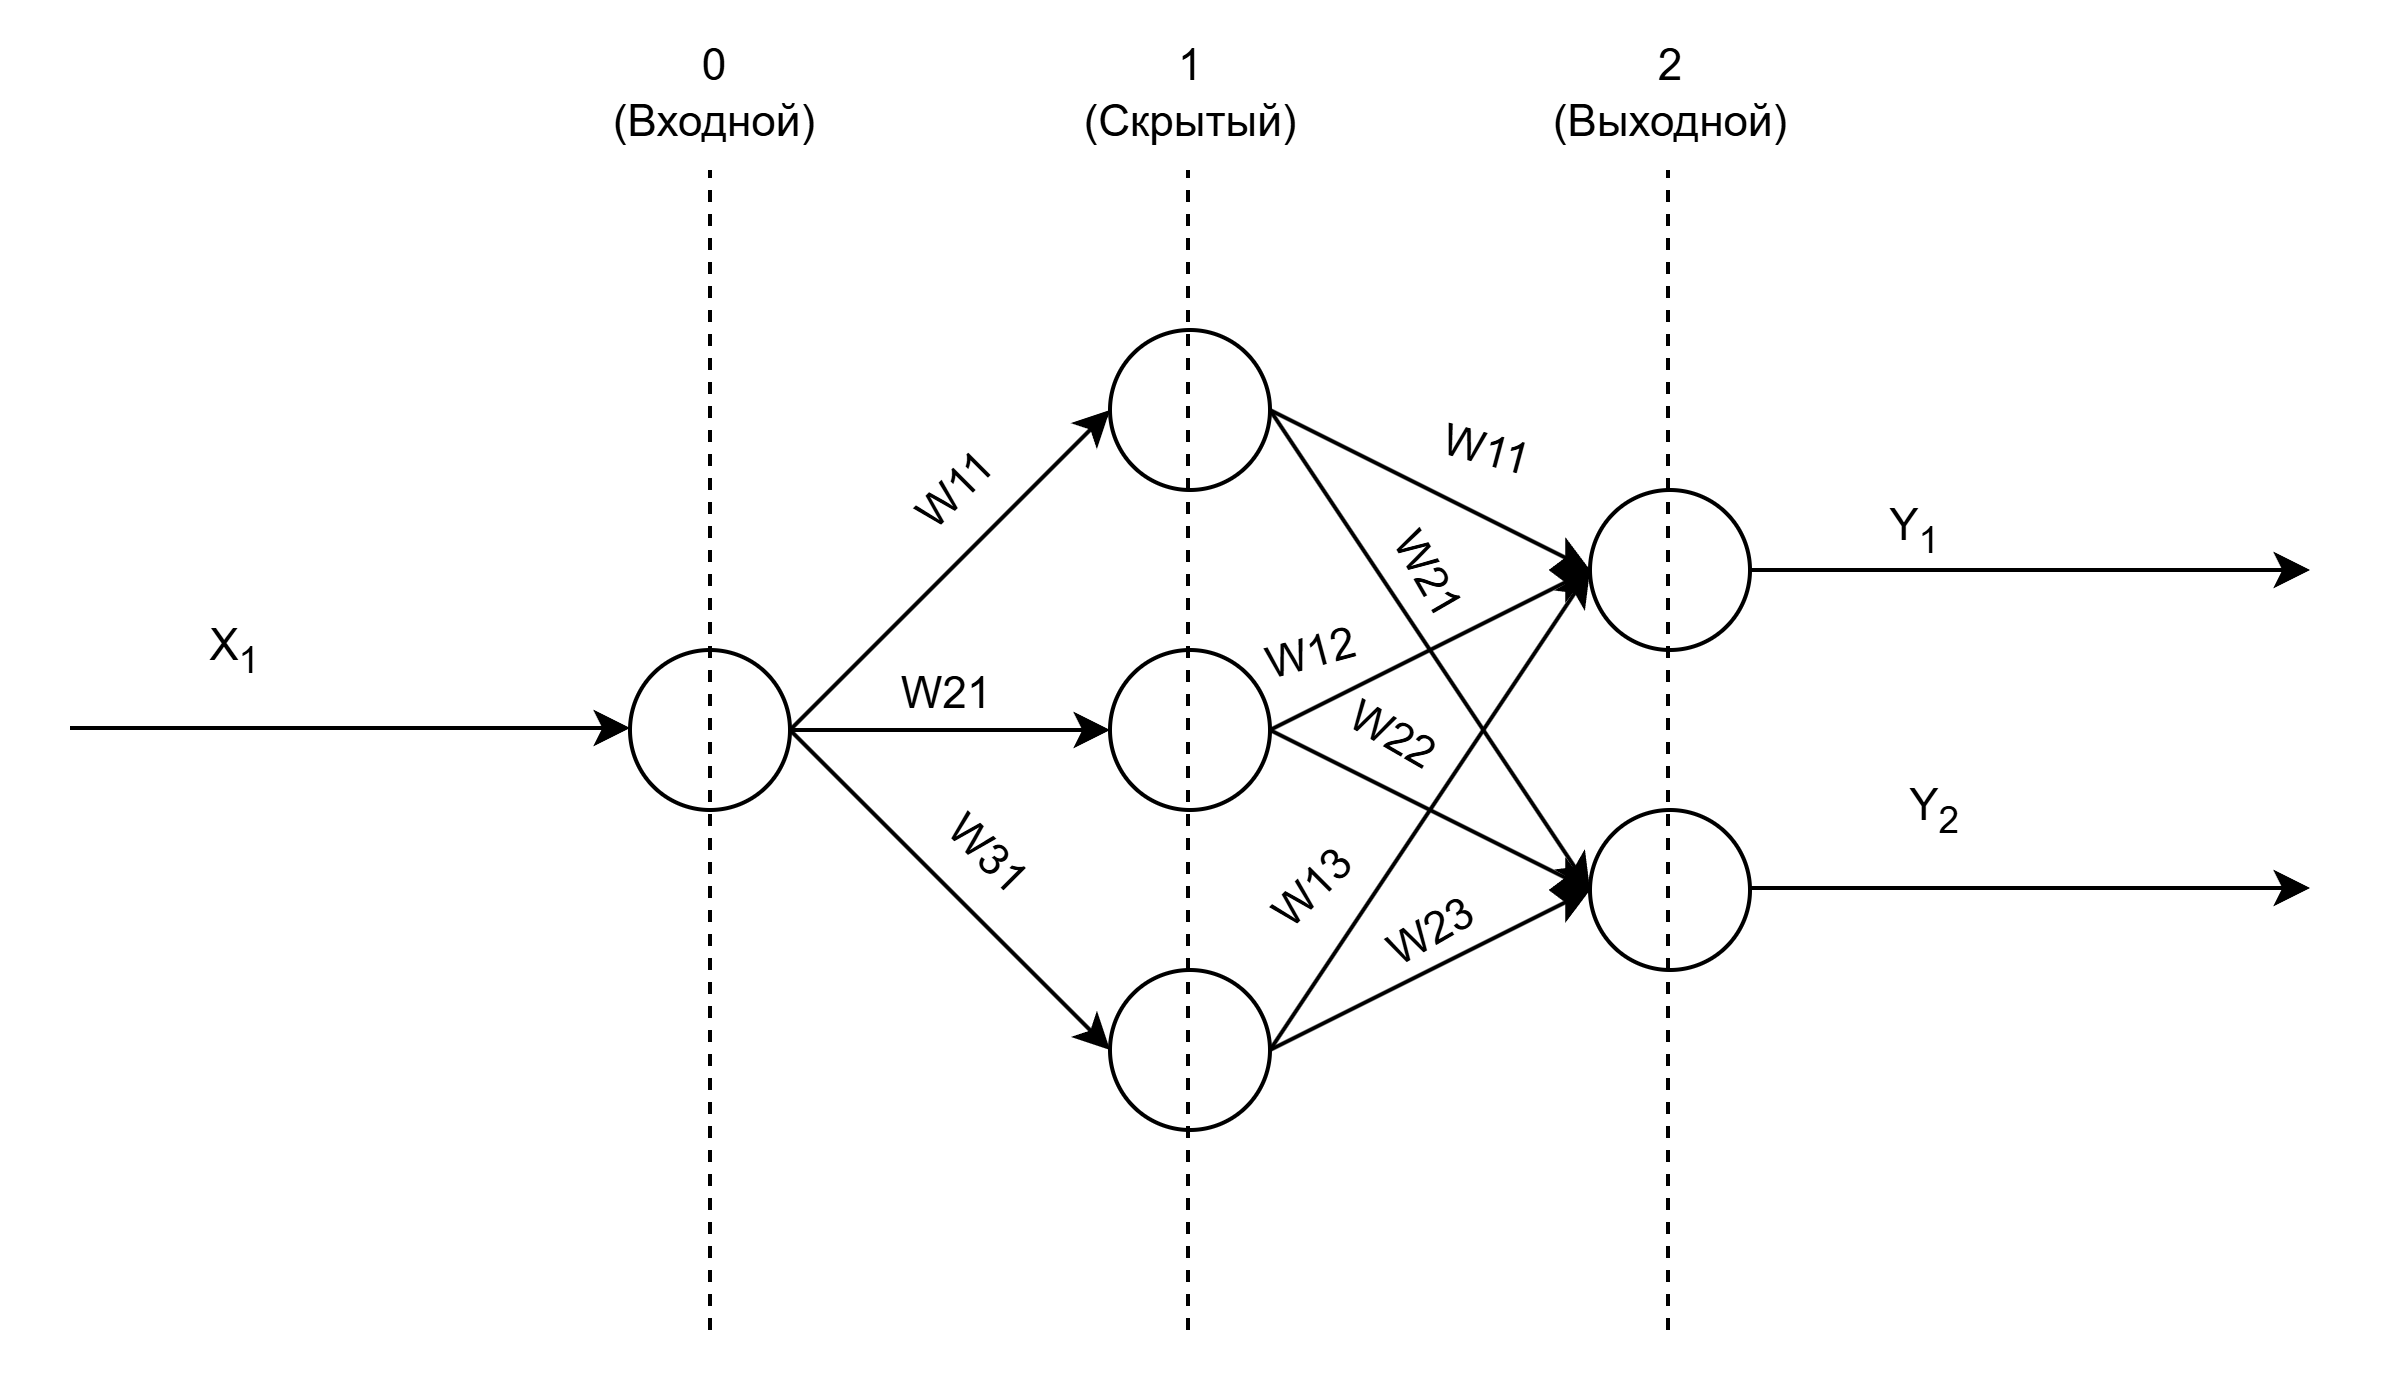

### 2. Создание математической модели нейронной сети согласно варианту

### 1. Первый (скрытый) слой

В этом слое каждый нейрон $j$ вычисляет взвешенную сумму входов $S_j^{(1)}$, а затем применяет к ней сигмоидную функцию активации для получения выхода $P_j$.

**Развернутая запись для каждого нейрона:**

**Первый нейрон скрытого слоя ($j=1$):**
$$ S_1^{(1)} = x_1 \cdot w_{11}^{(1)} $$
$$ P_1 = \frac{1}{1 + e^{-S_1^{(1)}}} $$

**Второй нейрон скрытого слоя ($j=2$):**
$$ S_2^{(1)} = x_1 \cdot w_{21}^{(1)} $$
$$ P_2 = \frac{1}{1 + e^{-S_2^{(1)}}} $$

**Третий нейрон скрытого слоя ($j=3$):**
$$ S_3^{(1)} = x_1 \cdot w_{31}^{(1)} $$
$$ P_3 = \frac{1}{1 + e^{-S_3^{(1)}}} $$

---

**Обобщенная формула для первого слоя:**

Для любого нейрона $j$ ($j = 1 \dots 3$) скрытого слоя:

$$ S_j^{(1)} = x_1 \cdot w_{j1}^{(1)} $$

$$ P_j = \frac{1}{1 + e^{-S_j^{(1)}}} $$

где:
- $x_1$ — единственный вход сети;
- $j$ — индекс нейрона в скрытом слое ($j = 1 \dots 3$);
- $w_{j1}^{(1)}$ — вес связи, идущей от входа $x_1$ к $j$-му нейрону скрытого слоя.

---

### 2. Второй (выходной) слой

В этом слое каждый нейрон $q$ вычисляет взвешенную сумму выходов скрытого слоя $S_q^{(2)}$, а затем применяет сигмоидную функцию активации.

**Развернутая запись для каждого выхода:**

**Первый выходной нейрон ($q=1$):**
$$ S_1^{(2)} = P_1 \cdot w_{11}^{(2)} + P_2 \cdot w_{12}^{(2)} + P_3 \cdot w_{13}^{(2)} $$
$$ Y_1 = \frac{1}{1 + e^{-S_1^{(2)}}} $$

**Второй выходной нейрон ($q=2$):**
$$ S_2^{(2)} = P_1 \cdot w_{21}^{(2)} + P_2 \cdot w_{22}^{(2)} + P_3 \cdot w_{23}^{(2)} $$
$$ Y_2 = \frac{1}{1 + e^{-S_2^{(2)}}} $$

---

**Обобщенная формула для второго слоя:**

Для любого выхода $q$ ($q = 1 \dots 2$) выходного слоя:

$$ S_q^{(2)} = \sum_{j=1}^{3} P_j \cdot w_{qj}^{(2)} $$

$$ Y_q = \frac{1}{1 + e^{-S_q^{(2)}}} $$

где:
- $j$ — индекс нейрона скрытого слоя ($j = 1 \dots 3$);
- $q$ — индекс нейрона выходного слоя ($q = 1 \dots 2$);
- $w_{qj}^{(2)}$ — вес связи, идущей от $j$-го скрытого нейрона к $q$-му выходному.

---

**Итоговая формула всей сети (в общем виде):**

Выход $Y_q$ вычисляется как:

$$ Y_q = \frac{1}{1 + e^{ -\sum_{j=1}^{3} \left( \frac{1}{1 + e^{-x_1 \cdot w_{j1}^{(1)}}} \right) \cdot w_{qj}^{(2)} }} $$

где $q = 1 \dots 2$.

## 3. Моделирование нейронной сети (практическое задание)

В этом разделе мы реализуем на Python модель двухслойной нейронной сети согласно варианту.

**Наша задача:**
1. Создать функцию `Neuron`, которая моделирует прямой проход сигнала через сеть (вход → скрытый слой → выход).
2. Создать функцию `Wes`, которая запускает сеть с тремя различными диапазонами случайных весов:
   - **$[-1; 0]$** — только отрицательные (тормозящие) связи;
   - **$[-1; 1]$** — смешанные веса;
   - **$[0; 1]$** — только положительные (возбуждающие) связи.
3. Подать на вход сети тестовые сигналы (линейный, пороговый, синусоидальный) и построить графики выходов.


### 3.1. Реализация модели нейронной сети

Сначала реализуем базовую функцию `Neuron`, которая моделирует прохождение сигнала через двухслойную сеть.

**Входные параметры функции:**
* `WS`: матрица весов первого слоя (вход → скрытый слой)
* `WV`: матрица весов второго слоя (скрытый → выходной слой)
* `Xx`: массив входных сигналов во времени
* `vx`: временная ось для графиков

Внутри функции происходит последовательное вычисление состояний нейронов скрытого слоя (с сигмоидной активацией) и выходного слоя (с линейной активацией).

In [ ]:
# Импорты
import random
import numpy as np
import matplotlib.pyplot as plt

# Диапазоны весов (базовый случай)
a = -1
b = 1

In [ ]:
def Neuron(WS, WV, Xx, vx, weight_label=""):
    """
    Прямой проход двухслойной сети:
    Xx: (1, T)   входной сигнал на T шагов времени
    WS: (3, 1)   веса вход -> скрытый (3 скрытых нейрона)
    WV: (2, 3)   веса скрытый -> выход (2 выходных нейрона)
    weight_label: подпись диапазона весов для заголовка
    """
    Y = np.zeros(2)
    S = np.zeros(3)
    P = np.zeros(3)
    s = np.zeros(2)
    y = np.zeros((2, Xx.shape[1]))

    for t in range(0, Xx.shape[1]):
        Y = np.zeros(2)
        S = np.zeros(3)
        P = np.zeros(3)
        s = np.zeros(2)

        # Скрытый слой
        for i in range(0, 3):
            for j in range(0, 1):
                S[i] = Xx[j, t] * WS[i, j] + S[i]
            P[i] = 1 / (1 + np.exp(-S[i]))

        # Выходной слой
        for i in range(0, 2):
            for j in range(0, 3):
                s[i] = P[j] * WV[i, j] + s[i]
            Y[i] = 1 / (1 + np.exp(-s[i]))
            y[i, t] = Y[i]

    # Визуализация выхода
    plt.figure(figsize=(10, 6))
    plt.grid(alpha=0.3)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.title(f'Выходы нейронной сети | {weight_label}', fontsize=13, fontweight='bold')
    plt.plot(vx, y[0], linewidth=2, label='Y1', marker='o', markersize=4)
    plt.plot(vx, y[1], linewidth=2, label='Y2', marker='s', markersize=4)
    plt.legend(fontsize=11)
    plt.tight_layout()

In [ ]:
def Wes(Xx, vx, a, b):
    # [0, b] - только положительные веса
    WS = np.random.uniform(0, b, (3, 1))
    WV = np.random.uniform(0, b, (2, 3))
    Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [0, {b}]")

    # [a, 0] - только отрицательные веса
    WS = np.random.uniform(a, 0, (3, 1))
    WV = np.random.uniform(a, 0, (2, 3))
    Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [{a}, 0]")

    # [a, b] - смешанные веса
    WS = np.random.uniform(a, b, (3, 1))
    WV = np.random.uniform(a, b, (2, 3))
    Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [{a}, {b}]")

### 3.2. Подготовка и визуализация входных данных

Сформируем тестовые сигналы, которые будем подавать на вход сети:
1.  **Линейный сигнал** (y = kx + b)
2.  **Пороговый сигнал** (ступенька)
3.  **Синусоидальный сигнал** (y = sin(x))

Построим графики этих входных сигналов, чтобы видеть, с чем будет работать наша нейронная сеть.

In [ ]:
k = random.uniform(-10, 10)

Xx = np.random.uniform(0, 1, (1, 20))
vx = np.linspace(-20, 20, 20)

for i in range(0, 20):
    Xx[0, i] = vx[i] * k + 3

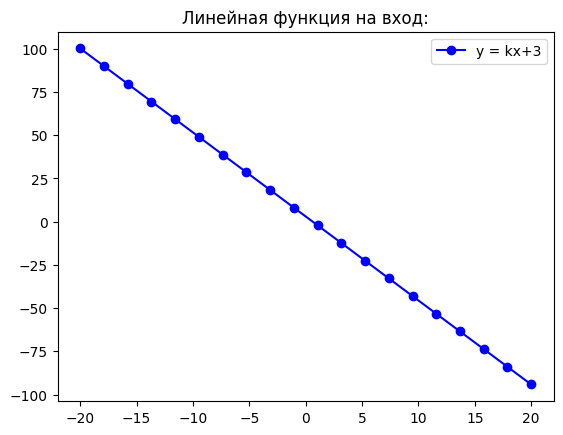

In [ ]:
plt.figure()
plt.title('Линейная функция на вход:')
plt.plot(vx, Xx[0], 'bo-', label='y = kx+3')
plt.legend()

### 3.3. Эксперименты с весами

Теперь проведем серию экспериментов, меняя диапазоны случайных весов. Это позволит увидеть, как начальная инициализация влияет на работу сети.

#### 3.3.1. Базовый эксперимент

Запустим моделирование для трех диапазонов весов. На графиках будут показаны выходы сети ($Y_1, Y_2, Y_3$) для каждого случая.

Обратите внимание, как меняется характер кривых в зависимости от знака весов. Напишите вывод.

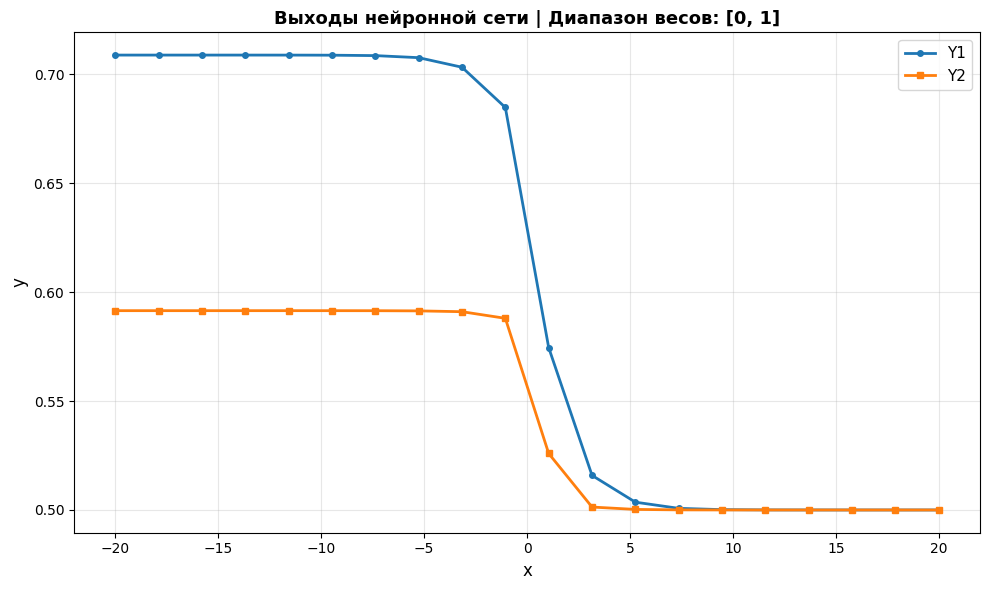

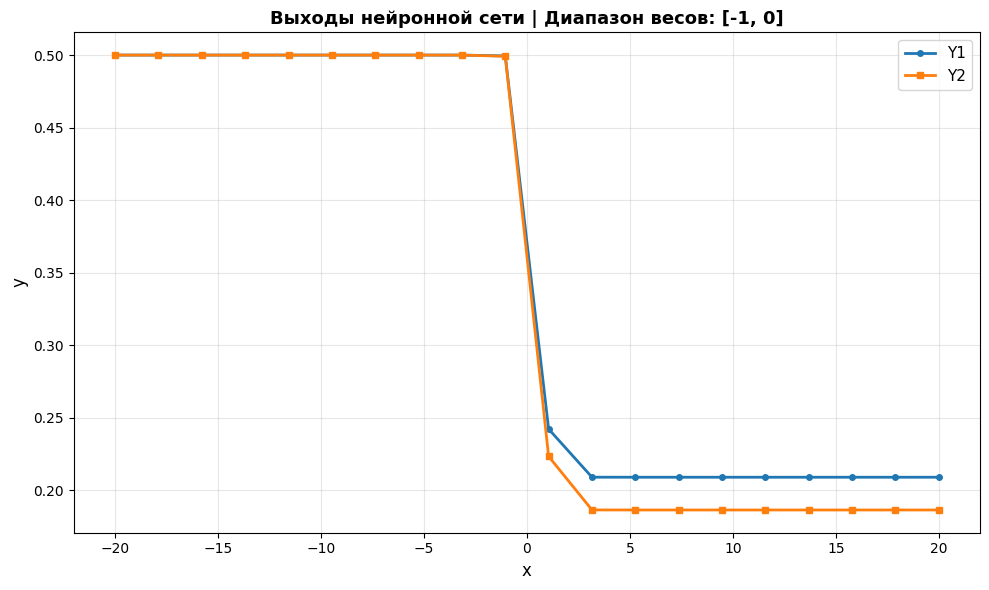

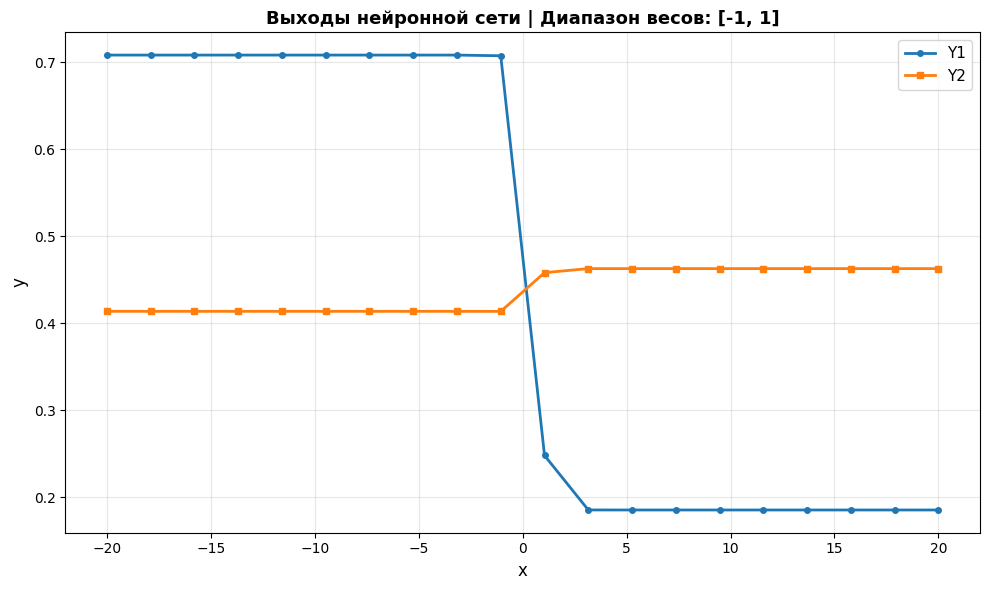

In [ ]:
# Базовые диапазоны
Wes(Xx, vx, a, b)
plt.show()

**Вывод:** (напишите здесь ваш вывод)

**ВЫВОД**: Диапазон '[0, 1]'
Выходные сигналы имеют положительную

1.   Выходные сигналы Y1, Y2, Y3 имеют положительную корреляцию с входными сигналами
2.   Форма кривых повторяет характер входных функций, но сглажена

Диапазон [-1 0]


1.   Выходные сигналы преимущественно отрицательные и убывающие. Сеть инвертирует и ослабляет входное воздействие

Диапазон [−1,1]


1.    Выходные сигналы могут принимать как положительные, так и отрицательные значения, а их форма становится более сложной и непредсказуемой, что указывает на более богатую динамику сети.







#### 3.3.2. Эксперимент с уменьшением весов в 10 раз

Запустите код ниже. Веса уменьшатся в 10 раз (диапазоны $[-0.1; 0]$, $[-0.1; 0.1]$, $[0; 0.1]$).

Обратите внимание, как меняется характер кривых в зависимости от изменения весов. Напишите вывод.

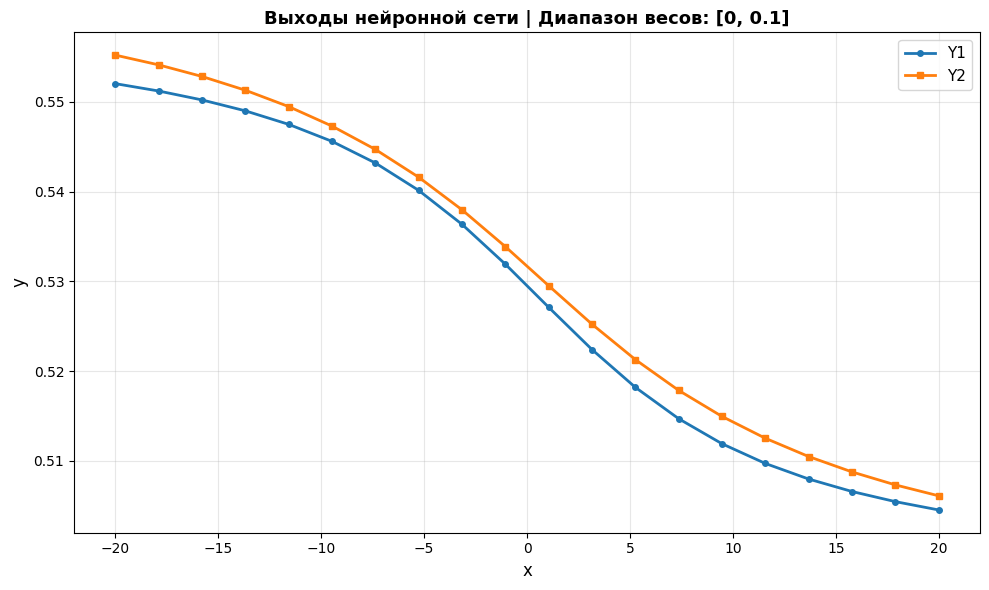

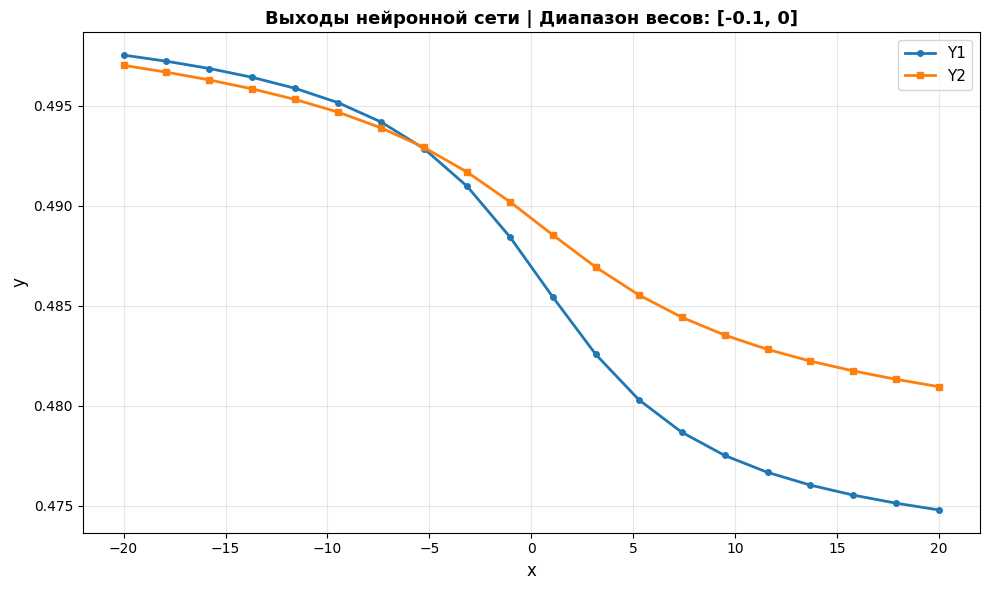

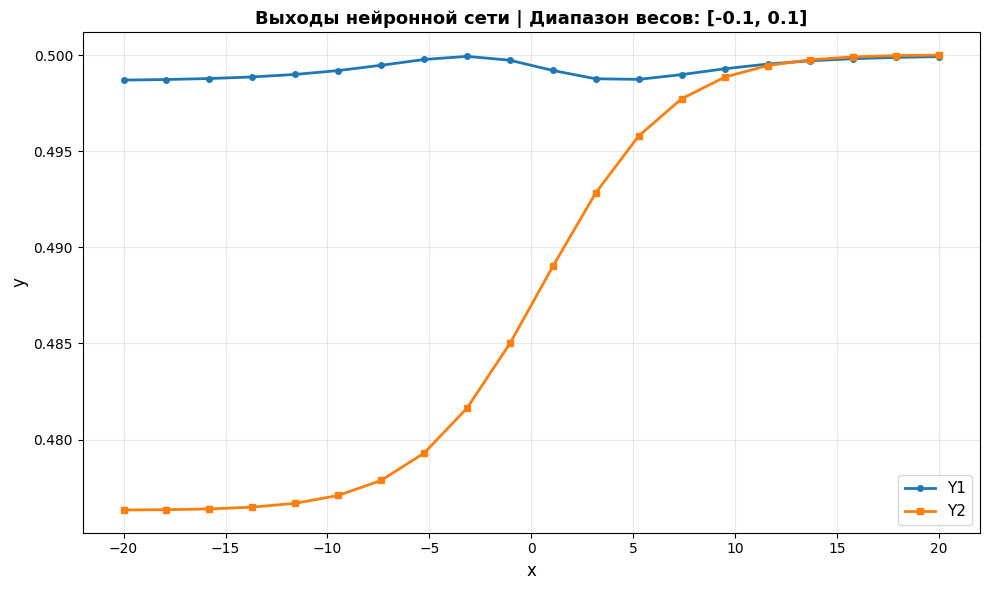

In [ ]:
# Уменьшение весов в 10 раз
Wes(Xx, vx, -0.1, 0.1) # Дописать код
plt.show()

**Вывод:** Диапазон [0, 0.1]


1.  Графики получились такой же формы, как в первом эксперименте, только значения стали примерно в 10 раз меньше. Это логично: маленькие веса дают маленький результат.


Диапазон [-0.1 0]


1.   Здесь графики тоже похожи на первый эксперимент, но уходят в минус. Из-за маленьких весов они стали ближе к нулю. Направление то же, а размах уменьшился.

Диапазон [-0.1 0.1]


1.   Графики также уменьшились по амплитуде по сравнению с первым экспериментом. Хорошо видно, что величина весов влияет на то, насколько сильно изменяются выходные сигналы.








#### 3.3.3. Эксперимент с увеличением весов в 10 раз

Запустите код ниже. Веса увеличатся в 10 раз (диапазоны $[-10; 0]$, $[-10; 10]$, $[0; 10]$).

Обратите внимание, как меняется характер кривых в зависимости от изменения весов. Напишите вывод.


/tmp/ipykernel_2510/3155646092.py:25: RuntimeWarning: overflow encountered in exp
  P[i] = 1 / (1 + np.exp(-S[i]))


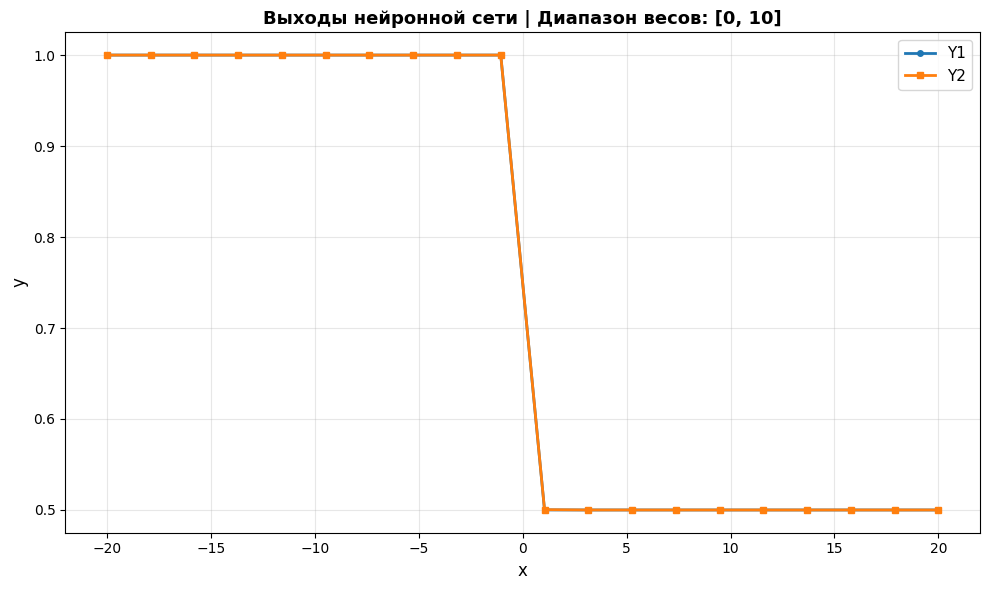

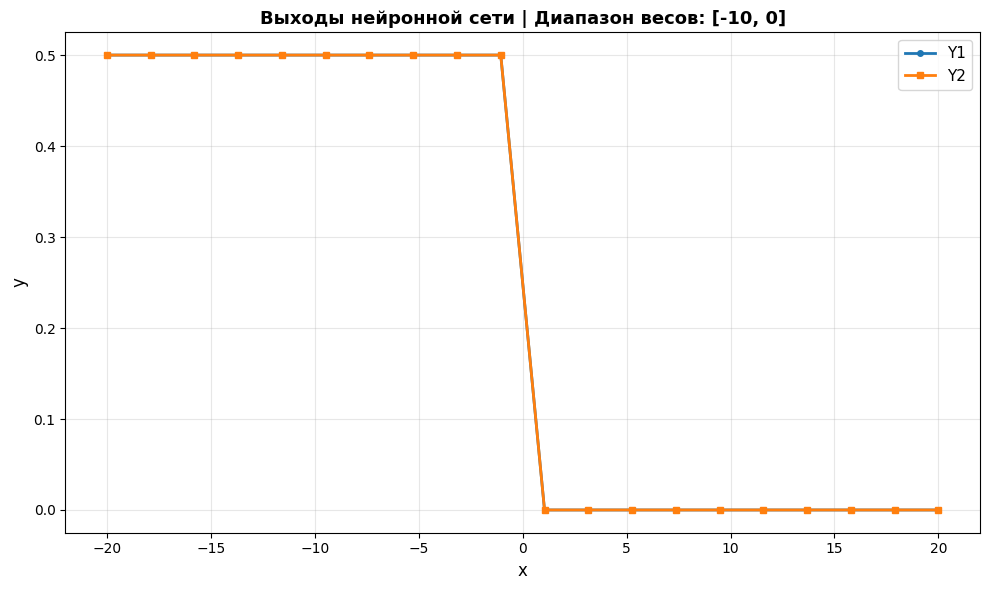

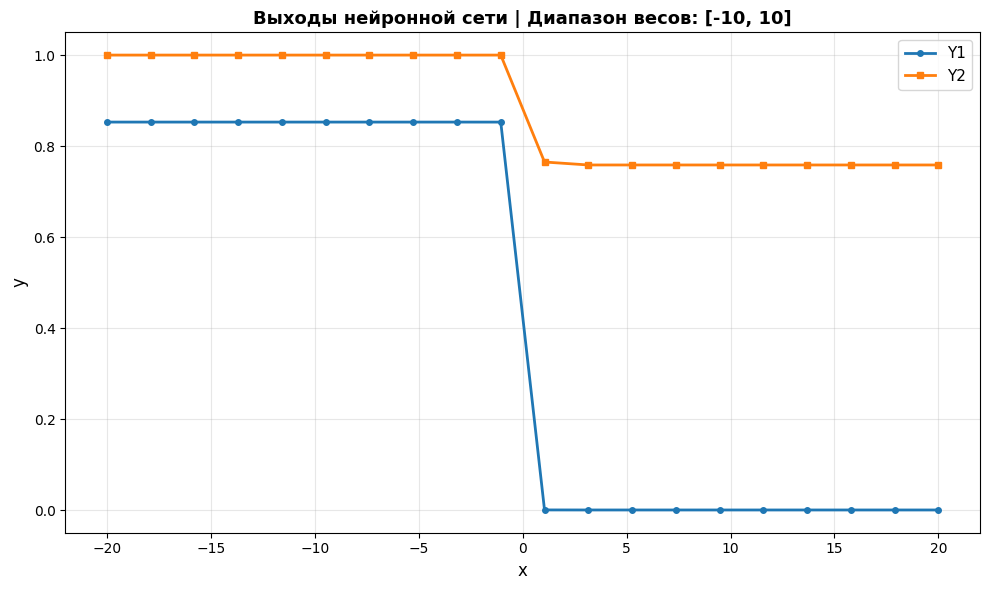

In [ ]:
# Увеличение весов в 10 раз
Wes(Xx, vx, -10, 10) # Дописать код
plt.show()

**Вывод:** Диапазон [0 10]


1.   Графики выходов сохранили возрастающую форму, но значения стали примерно в 10 раз больше, чем в бахзовом эксперименте.
Чем больше веса, тем сильнее сеть усиливает входной сигнал

Диапазон [-10 0]


1.   Графики остались убывающими и отрицательными, но их амплитуда также выросла в 10 раз. Отрицательные веса по-прежнему инвертируют сигнал, а их величина определяет, насколько сильно

Диапазон [-10 10]


1.    Выходные сигналы стали гораздо более резкими и контрастными. Из-за больших весов даже небольшие изменения во входных данных вызывают сильные колебания на выходе. Это показывает, что слишком большая инициализация весов может сделать сеть нестабильной










### 4. Общий вывод

Напишите краткий вывод по проделанной работе.
Опишите, как изменение **диапазона начальных весов** (отрицательные/положительные, малые/большие) влияет на характер выходных сигналов нейронной сети.
(3-4 предложения).




В ходе работы было исследовано влияние инициализации весов на выходные сигналы нейронной сети. Знак весов определяет направление изменения сигнала: положительные веса дают возрастающие графики, отрицательные — убывающие. Величина весов амплитуду выходных сигналов: чем больше веса, тем сильнее сеть усиливает входные данные, а слишком маленькие веса, наоборот, приводят к слабой реакции сети. Таким образом, правильный выбор начальных весов критически важен для дальнейшего обучения сети.



### 5. Контрольные вопросы

1.  **Понятие нейрона. Его математическая модель.** (Из каких основных блоков состоит искусственный нейрон?)

Нейрон — это структурно‑функциональная единица нервной системы, специализированная клетка, которая принимает, обрабатывает и передаёт информацию в виде электрохимических сигналов.




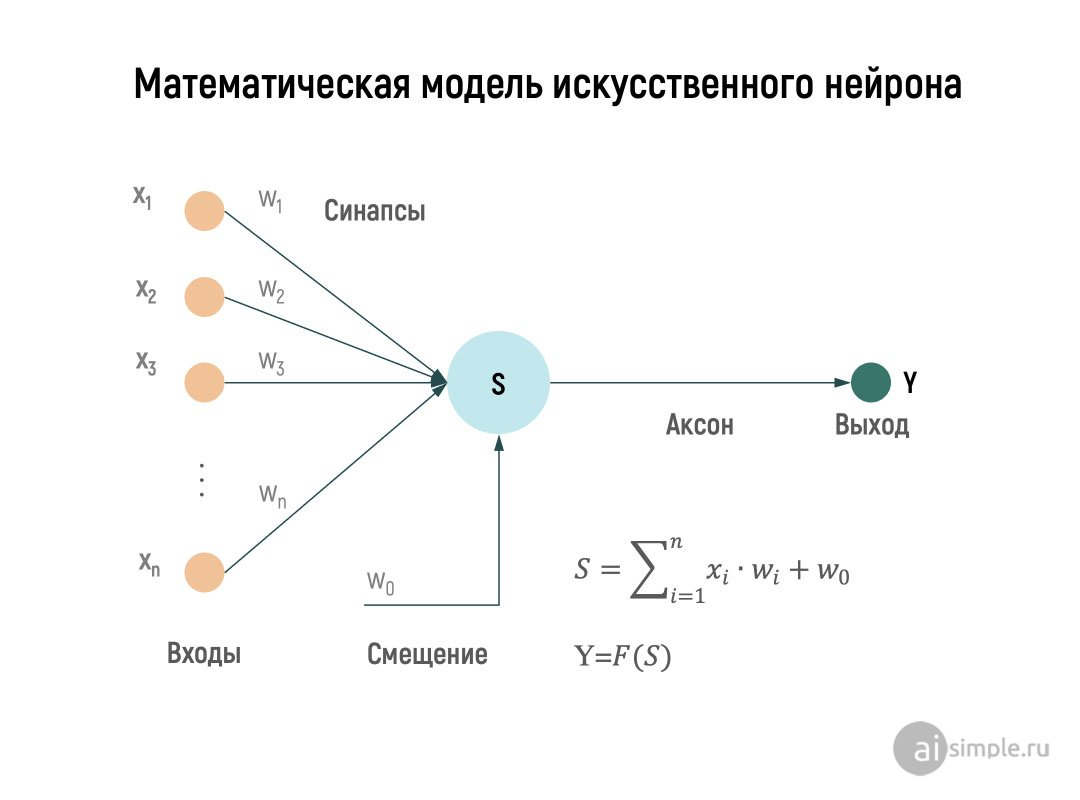

Источник: https://aisimple.ru/27-iskusstvenniy-neiron.html

2.  **Нейронная сеть.** (Что это такое и зачем нужно объединять нейроны?)

**Нейронная сеть** — это математическая модель, состоящая из множества соединенных между собой искусственных нейронов.

**Искусственный нейрон** (формальный нейрон, перцептронный элемент) рассматривается как вычислительный блок, который принимает на вход вектор чисел и возвращает одно число — выходной сигнал.



*   Чтобы нейросеть могла обучаться сложным вещам (распознавать лица, переводить
тексты, играть в игры), нейроны объединяют в слои, а слои — в сети.

3.  **Свойства сигмоидальной функции активации.** (Почему она так популярна? Какой у нее диапазон значений?)

**Логистическая сигмоида:**

$$f(s) = \frac{1}{1 + e^{-a s}}, \quad s \in (-\infty, \infty)$$

где $a > 0$ задаёт «крутизну» перехода. Эта функция:
- ограничена на интервале $(0, 1)$,
- гладка и дифференцируема на всей оси,
- имеет простую производную:
  $$f'(s) = a f(s)(1 - f(s))$$

что удобно для алгоритмов обучения по градиенту.



4.  **Области применения НС.** (Назовите 2-3 задачи, где нейросети работают лучше обычных алгоритмов).




*   Распознавание и классификация изображений
*   Обработка текстов
*   Распознавание речи
5.  **Однослойные и многослойные НС.** (В чем главное отличие по возможностям решения задач?)



*   **Однослойные сети** могут решать только линейные задачи. Они способны разделять пространство признаков прямой линией
*   **Многослойные сети** могут решать нелинейные задачи. Благодаря наличию одного или нескольких скрытых слоев они способны выделять более сложные закономерности и разделять данные кривыми линиями. Именно многослойные сети используются для распознавания образов, анализа текста и других сложных задач, где данные не разделяются линейно.
6.  **Линейность vs Нелинейность.** (В чем принципиальная разница между линейной функцией активации и нелинейной (например, сигмоидой)? Почему для решения сложных задач необходима нелинейность?)

**Линейная функция активации**
Напоминает прямую линию. Возвращает входное значение без изменений: f(x) = x.

Особенности:


-   Область значений не ограничена: от отрицательной бесконечности до положительной бесконечности.
-   Если все слои нейронной сети используют линейную функцию активации, результат представляет собой линейную комбинацию входных данных.
- Используется только в одном месте — на выходном слое. Использование линейной активации на всех уровнях ограничивает способность сети изучать сложные паттерны.


**Нелинейная функция активации** (сигмоида или ReLU) — это кривая, которая может изгибаться и менять форму. Она привносит в работу сети нелинейность.

Нелинейность необходима для решения сложных задач, так как позволяет учитывать сложные зависимости между переменными. Это позволяет учитывать реальные процессы, которые часто включают в себя квадратичные, экспоненциальные, логарифмические или другие нелинейные отношения.
